  Student_ID   Age  Gender  StudyHoursPerDay  SocialMediaHours  \
0      S1138  23.0    Male               3.9               3.3   
1      S1003   NaN  Female               1.0               NaN   
2      S1835  20.0  Female               5.1               2.6   
3      S1891  23.0    Male               2.2              14.6   
4      S1374   NaN    Male               2.8               2.0   

   PassiveEntertainmentHrs  PoR  AttendancePercentage  SleepHoursPerNight  \
0                      0.5  0.0                  87.0                 8.5   
1                      1.0  0.0                  71.0                 9.2   
2                      1.8  0.0                  83.4                 6.5   
3                      2.0  1.0                  85.3                 6.5   
4                      4.1  NaN                  82.3                 6.3   

  Diet_Quality  Exercise_frequency parental_education_level internet_quality  \
0         Fair                 4.0                   Master 

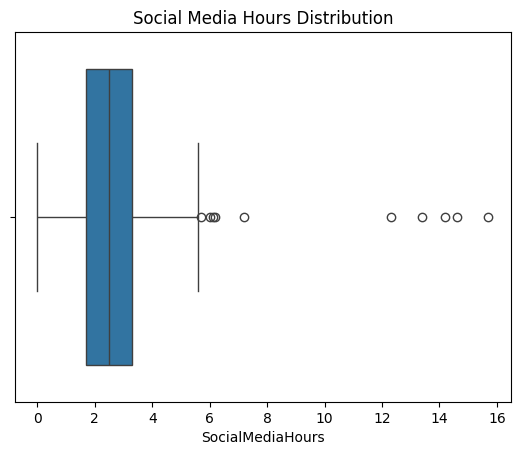

  Student_ID   Age  Gender  StudyHoursPerDay  SocialMediaHours  \
0      S1138  23.0    Male               3.9               3.3   
1      S1003  20.0  Female               1.0               2.5   
2      S1835  20.0  Female               5.1               2.6   
3      S1891  23.0    Male               2.2               5.7   
4      S1374  20.0    Male               2.8               2.0   

   PassiveEntertainmentHrs  PoR  AttendancePercentage  SleepHoursPerNight  \
0                      0.5  0.0                  87.0                 8.5   
1                      1.0  0.0                  71.0                 9.2   
2                      1.8  0.0                  83.4                 6.5   
3                      2.0  1.0                  85.3                 6.5   
4                      4.1  0.0                  82.3                 6.3   

  Diet_Quality  Exercise_frequency parental_education_level internet_quality  \
0         Fair                 4.0                   Master 

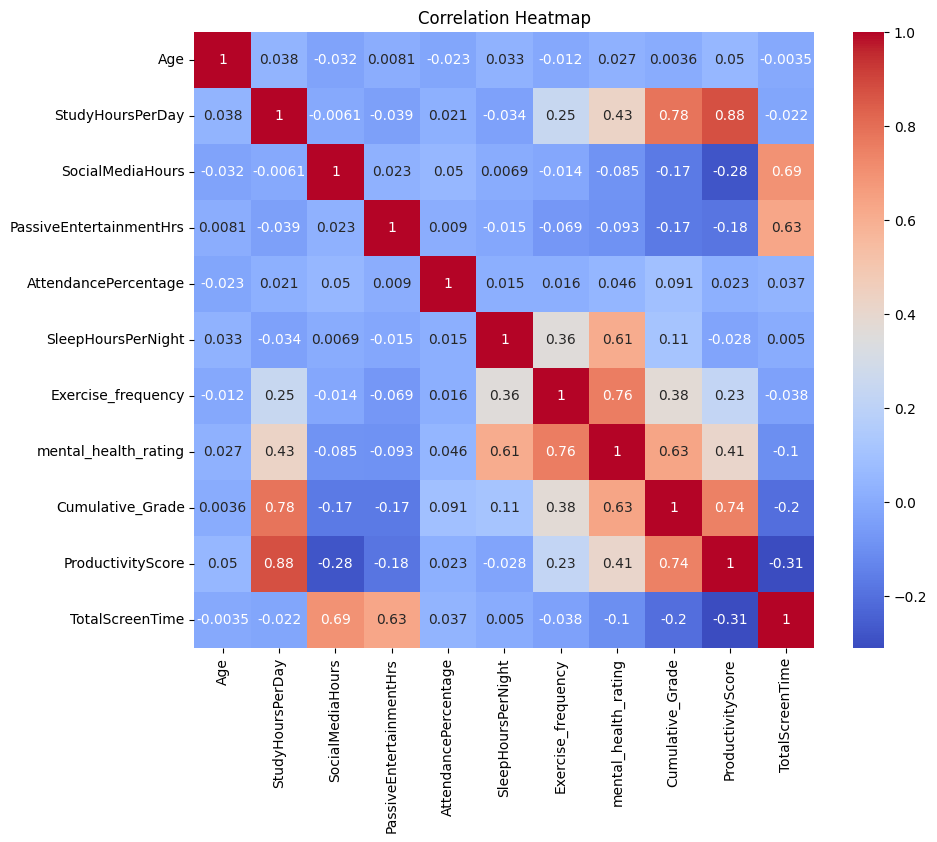

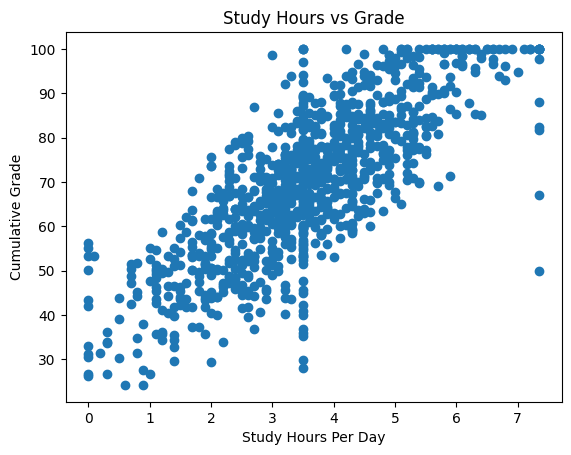

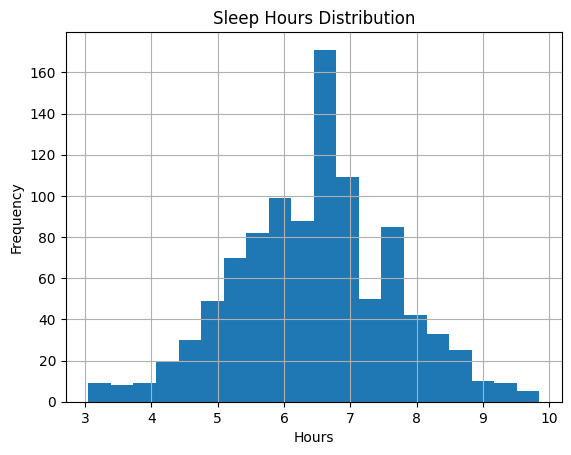

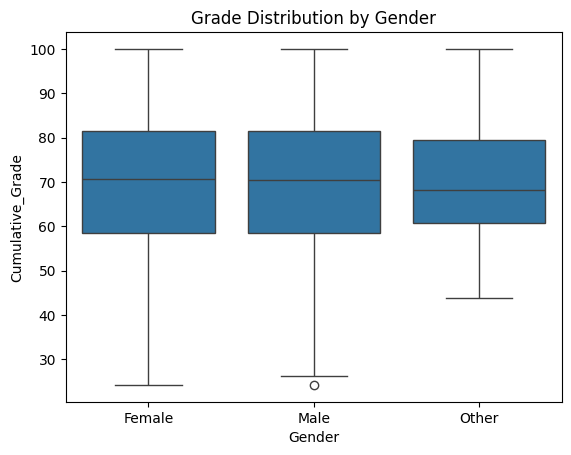

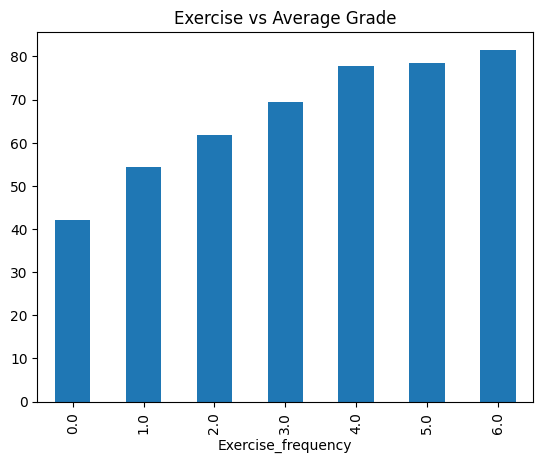

In [1]:
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt



def clean_exercise_frequency(value):
    if pd.isna(value):
        return None
    
    value = str(value)
    
    match = re.search(r'\d+(\.\d+)?', value)
    
    if match:
        return float(match.group())
    else:
        return None



df = pd.read_excel("/kaggle/input/datasets/purplecat07/iitb-ug-student-dataset-xlsx/IITB_UG_Student_Dataset_.xlsx")


df['Exercise_frequency'] = df['Exercise_frequency'].apply(clean_exercise_frequency)

num_cols = ['Age', 'StudyHoursPerDay', 'SocialMediaHours', 'PassiveEntertainmentHrs',
'AttendancePercentage', 'SleepHoursPerNight', 'Exercise_frequency', 'mental_health_rating',
'Cumulative_Grade', 'ProductivityScore', 'TotalScreenTime']

bin_cols = ['PoR', 'SleepDebt', 'extracurricular_participation']

cat_cols = ['Gender', 'Diet_Quality', 'parental_education_level']

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

for col in bin_cols:
    df[col] = df[col].map({
    'Yes': 1,
    'No': 0
    })
  # df[col] = df[col].astype('bool')


print(df.head())
print(df.info())

summary = pd.DataFrame({
    'Mean': df[num_cols].mean(),
    'Median': df[num_cols].median(),
    'Std Dev': df[num_cols].std()
})

sns.boxplot(x=df['SocialMediaHours'])
plt.title("Social Media Hours Distribution")
plt.show()

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)
    df[col] = df[col].fillna(summary.Median[col])

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
    df[col] = df[col].astype('category')

for col in bin_cols:
    df[col] = df[col].fillna(0)

print(df.head())
print(df.info())

print(summary)

corr = df[num_cols].corr()
print()
print(corr['Cumulative_Grade'].sort_values(ascending=False))
print()
print(corr['AttendancePercentage'].sort_values(ascending=False))
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


plt.scatter(df['StudyHoursPerDay'], df['Cumulative_Grade'])
plt.xlabel("Study Hours Per Day")
plt.ylabel("Cumulative Grade")
plt.title("Study Hours vs Grade")
plt.show()

df['SleepHoursPerNight'].hist(bins=20)
plt.title("Sleep Hours Distribution")
plt.xlabel("Hours")
plt.ylabel("Frequency")
plt.show()

sns.boxplot(x='Gender', y='Cumulative_Grade', data=df)
plt.title("Grade Distribution by Gender")
plt.show()

df.groupby('Exercise_frequency')['Cumulative_Grade'].mean().plot(kind='bar')
plt.title("Exercise vs Average Grade")
plt.show()

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import os
import pandas as pd




# Features & target
X = df[num_cols].drop(columns=['Cumulative_Grade'])
y = df['Cumulative_Grade']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Models
lr = LinearRegression()
rf = RandomForestRegressor(random_state=42)

# Train
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

# Predictions
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)

# Metrics
def evaluate(y_true, y_pred, name):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    
    print(f"\n{name} Performance:")
    print("R2:", r2)
    print("RMSE:", rmse)
    print("MAE:", mae)

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_rf, "Random Forest")




Linear Regression Performance:
R2: 0.7759414114851706
RMSE: 8.205761366145932
MAE: 5.8897884037242125

Random Forest Performance:
R2: 0.7289482843150294
RMSE: 9.02535234228355
MAE: 6.475348258706468


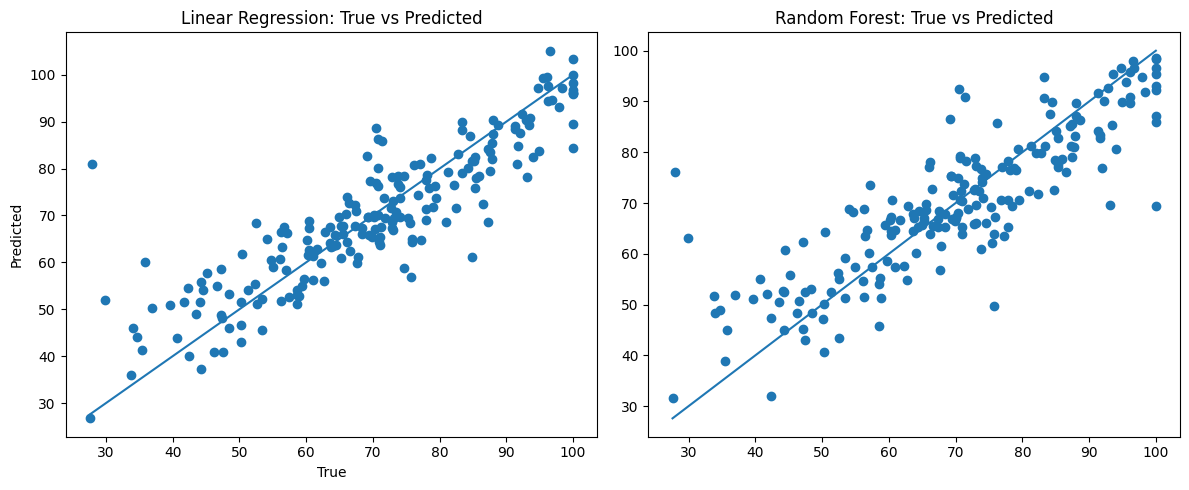

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Linear Regression
axes[0].scatter(y_test, y_pred_lr)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
axes[0].set_title("Linear Regression: True vs Predicted")
axes[0].set_xlabel("True")
axes[0].set_ylabel("Predicted")

# Random Forest
axes[1].scatter(y_test, y_pred_rf)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
axes[1].set_title("Random Forest: True vs Predicted")

plt.tight_layout()
plt.show()

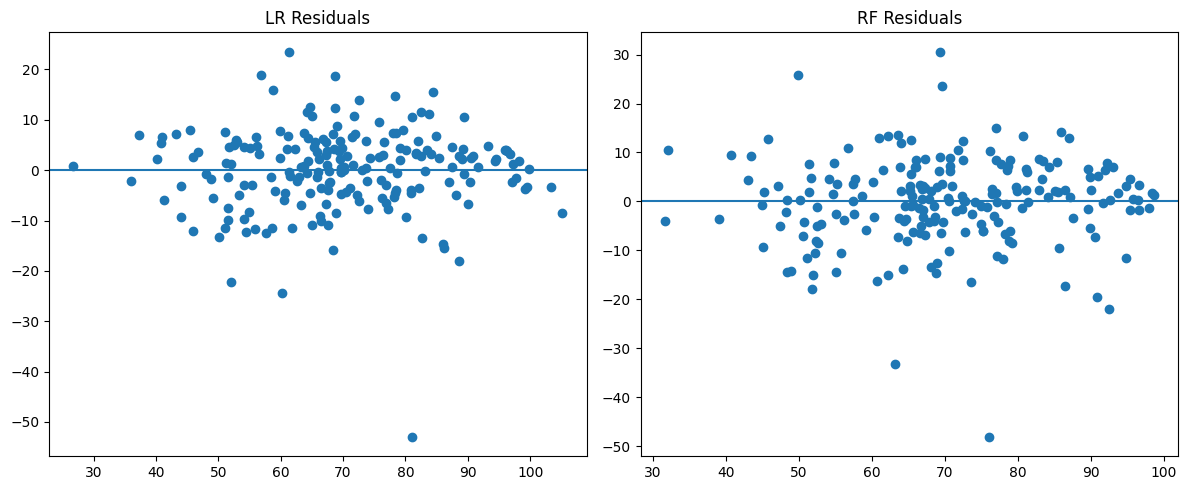

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Residuals = actual - predicted
res_lr = y_test - y_pred_lr
res_rf = y_test - y_pred_rf

axes[0].scatter(y_pred_lr, res_lr)
axes[0].axhline(0)
axes[0].set_title("LR Residuals")

axes[1].scatter(y_pred_rf, res_rf)
axes[1].axhline(0)
axes[1].set_title("RF Residuals")

plt.tight_layout()
plt.show()

In [5]:
metrics = ['R2', 'RMSE', 'MAE']

data = [
    {"metric": "R2", "Linear Regression": r2_score(y_test, y_pred_lr), "Random Forest": r2_score(y_test, y_pred_rf)},
    {"metric": "RMSE", "Linear Regression": np.sqrt(mean_squared_error(y_test, y_pred_lr)), "Random Forest": np.sqrt(mean_squared_error(y_test, y_pred_rf))},
    {"metric": "MAE", "Linear Regression": mean_absolute_error(y_test, y_pred_lr), "Random Forest": mean_absolute_error(y_test, y_pred_rf)}
]

print(data)

[{'metric': 'R2', 'Linear Regression': 0.7759414114851706, 'Random Forest': 0.7289482843150294}, {'metric': 'RMSE', 'Linear Regression': np.float64(8.205761366145932), 'Random Forest': np.float64(9.02535234228355)}, {'metric': 'MAE', 'Linear Regression': 5.8897884037242125, 'Random Forest': 6.475348258706468}]
